In [10]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# -------------------------------------------------
# Create Environment
# -------------------------------------------------

env = gym.make("FrozenLake-v1", is_slippery=False)
n_states = env.observation_space.n
n_actions = env.action_space.n

print(f"Number of states: {n_states}")
print(f"Number of actions: {n_actions}")

Number of states: 16
Number of actions: 4


In [12]:

# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 20000
gamma = 0.99
alpha = 0.1

epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

max_steps_per_episode = 100



In [13]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))
episode_rewards = []


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    if np.random.rand() < epsilon:
        return env.action_space.sample()  # Explore
    else:
        return np.argmax(Q[state, :])  # Exploit


# -------------------------------------------------
# Generate One Complete Episode
# -------------------------------------------------

def generate_episode(epsilon):
    """
    Generates one episode using the current epsilon-greedy policy.
    Returns a list of (state, action, reward).
    """

    episode = []

    state, info = env.reset()

    for _ in range(max_steps_per_episode):
        action = epsilon_greedy_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)

        episode.append((state, action, reward))

        state = next_state

        if terminated or truncated:
            break

    return episode

In [14]:
# The content of this cell has been moved to p2VB_P87MdTP for correct execution order.

In [15]:
# -------------------------------------------------
# Monte Carlo Control
# -------------------------------------------------

epsilon = epsilon_start

for episode_idx in range(num_episodes):
    episode = generate_episode(epsilon)

    # Calculate total reward for the episode
    total_reward = sum([reward for state, action, reward in episode])
    episode_rewards.append(total_reward)

    # Update Q-table (First-Visit Monte Carlo)
    visited_state_actions = set()
    G = 0  # Initialize return G

    for i in reversed(range(len(episode))):
        state, action, reward = episode[i]
        G = gamma * G + reward

        if (state, action) not in visited_state_actions:
            Q[state, action] = Q[state, action] + alpha * (G - Q[state, action])
            visited_state_actions.add((state, action))

    # Epsilon decay
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (episode_idx + 1) % 1000 == 0:
        print(f"Episode {episode_idx + 1}/{num_episodes}, Epsilon: {epsilon:.4f}, Avg Reward (last 1000): {np.mean(episode_rewards[-1000:]):.4f}")

Episode 1000/20000, Epsilon: 0.6065, Avg Reward (last 1000): 0.1050
Episode 2000/20000, Epsilon: 0.3678, Avg Reward (last 1000): 0.3810
Episode 3000/20000, Epsilon: 0.2230, Avg Reward (last 1000): 0.6460
Episode 4000/20000, Epsilon: 0.1353, Avg Reward (last 1000): 0.7750
Episode 5000/20000, Epsilon: 0.0820, Avg Reward (last 1000): 0.8670
Episode 6000/20000, Epsilon: 0.0500, Avg Reward (last 1000): 0.9060
Episode 7000/20000, Epsilon: 0.0500, Avg Reward (last 1000): 0.9370
Episode 8000/20000, Epsilon: 0.0500, Avg Reward (last 1000): 0.9390
Episode 9000/20000, Epsilon: 0.0500, Avg Reward (last 1000): 0.9170
Episode 10000/20000, Epsilon: 0.0500, Avg Reward (last 1000): 0.9340
Episode 11000/20000, Epsilon: 0.0500, Avg Reward (last 1000): 0.9300
Episode 12000/20000, Epsilon: 0.0500, Avg Reward (last 1000): 0.9320
Episode 13000/20000, Epsilon: 0.0500, Avg Reward (last 1000): 0.9440
Episode 14000/20000, Epsilon: 0.0500, Avg Reward (last 1000): 0.9420
Episode 15000/20000, Epsilon: 0.0500, Avg R

In [16]:
# -------------------------------------------------
# Extract Greedy Policy
# -------------------------------------------------

optimal_policy = np.argmax(Q, axis=1)
state_values = np.max(Q, axis=1)


In [17]:
def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)
    print("Name: Subikshan P")
    print("Register Number: 212223240161")
    print("\nLearned Policy:")
    print(policy_grid)

In [19]:
def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))

In [20]:
print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(optimal_policy)

success_rate = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", success_rate)


Final Q-table:
[[0.616 0.591 0.858 0.547]
 [0.481 0.    0.952 0.445]
 [0.553 0.962 0.589 0.743]
 [0.595 0.    0.327 0.443]
 [0.548 0.622 0.    0.68 ]
 [0.    0.    0.    0.   ]
 [0.    0.98  0.    0.741]
 [0.    0.    0.    0.   ]
 [0.571 0.    0.699 0.67 ]
 [0.834 0.799 0.849 0.   ]
 [0.931 0.99  0.    0.966]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.961 0.988 0.821]
 [0.979 0.989 1.    0.978]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.858 0.952 0.962 0.595]
 [0.68  0.    0.98  0.   ]
 [0.699 0.849 0.99  0.   ]
 [0.    0.988 1.    0.   ]]
Name: Subikshan P
Register Number: 212223240161

Learned Policy:
[['R' 'R' 'D' 'L']
 ['U' 'L' 'D' 'L']
 ['R' 'R' 'D' 'L']
 ['L' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 0.912


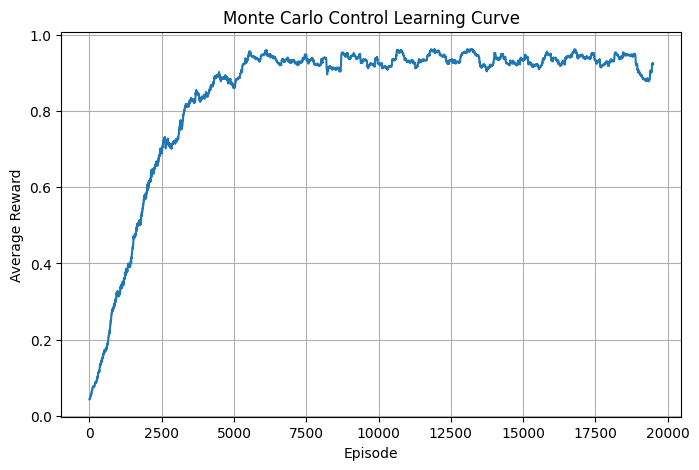

In [18]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500
moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Monte Carlo Control Learning Curve")
plt.grid(True)
plt.show()

env.close()